# FarmTrust — `aoi_demo_01` cube & assessment

Visualizes the **cube-path ingestion** (`cube.zarr`) and the full downstream chain
(preprocess → seasonal → assessment) for the 2-year demo AOI.

Reads only on-disk artifacts produced by:

```
uv run ingest-aoi --config scripts/ingest_demo.json --force-rerun
uv run python scripts/preprocess_timeseries.py --aoi-id aoi_demo_01
uv run python scripts/seasonal_analysis.py    --aoi-id aoi_demo_01
uv run python scripts/land_assessment.py      --aoi-id aoi_demo_01
```

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

AOI = "aoi_demo_01"

# Walk up to the repo root so the notebook runs from anywhere.
ROOT = Path.cwd()
while not (ROOT / "data" / AOI / "cube.zarr").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
D = ROOT / "data"

cube = xr.open_zarr(D / AOI / "cube.zarr", consolidated=False)
sm = pd.read_csv(D / "preprocess" / AOI / "ndvi_smoothed.csv", parse_dates=["timestamp"])
quality = json.loads((D / "preprocess" / AOI / "quality_metrics.json").read_text())
seasons = json.loads((D / "seasonal" / AOI / "season_windows.json").read_text())
assess = json.loads((D / "assessment" / AOI / "land_assessment.json").read_text())

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

print(f"AOI {AOI}  |  cube {dict(cube.sizes)}  |  obs {len(sm)}  |  "
      f"seasons {seasons['season_count']}  |  status {assess['land_status']}  |  "
      f"confidence {assess['confidence']['level']}")

AOI aoi_demo_01  |  cube {'time': 280, 'y': 6, 'x': 18}  |  obs 280  |  seasons 4  |  status active  |  confidence medium


## 1. NDVI time series — raw, filled, and smoothed

Raw per-solar-day NDVI remains visible as audit evidence. The analysis curve fills missing/low-quality timestamps within the observed record and then applies Savitzky-Golay smoothing. Detected vegetation activity windows are shaded **gold**; long observation gaps remain shaded **red** as confidence evidence.


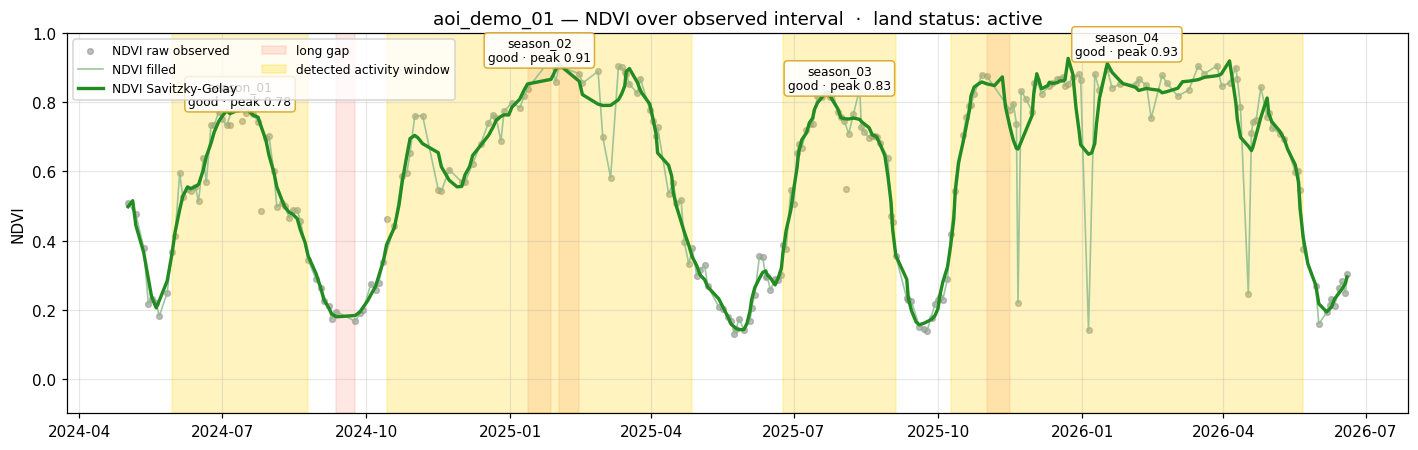

In [2]:
seas = seasons["seasons"]
gaps = quality["long_gap_windows"]

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.scatter(sm.timestamp, sm.ndvi_raw, s=14, color="0.55", alpha=0.55, label="NDVI raw observed")
if "ndvi_filled" in sm.columns:
    ax.plot(sm.timestamp, sm.ndvi_filled, color="darkseagreen", lw=1.1, alpha=0.85, label="NDVI filled")
ax.plot(sm.timestamp, sm.ndvi_smoothed, color="forestgreen", lw=2.2, label="NDVI Savitzky-Golay")

for i, g in enumerate(gaps):
    ax.axvspan(pd.Timestamp(g["start_timestamp"]), pd.Timestamp(g["end_timestamp"]),
               color="tomato", alpha=0.15, label="long gap" if i == 0 else None)
for i, s in enumerate(seas):
    s0, s1 = pd.Timestamp(s["start_date"]), pd.Timestamp(s["end_date"])
    ax.axvspan(s0, s1, color="gold", alpha=0.25, label="detected activity window" if i == 0 else None)
    ax.annotate(f"{s['season_id']}\n{s['quality_label']} · peak {s['peak_ndvi']:.2f}",
                (s0 + (s1 - s0) / 2, s["peak_ndvi"]), ha="center", va="bottom", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", ec="goldenrod", alpha=0.9))

ax.set_title(f"{AOI} — NDVI over observed interval  ·  land status: {assess['land_status']}")
ax.set_ylabel("NDVI"); ax.set_ylim(-0.1, 1.0)
ax.legend(loc="upper left", ncol=2, fontsize=8)
fig.tight_layout(); plt.show()


**What the NDVI series shows**

- The reconstructed analysis curve now captures **four confirmed vegetation activity windows** across the observed interval, including the winter 2024-25 cycle and the late-2025 to spring-2026 plateau.
- Gap filling is used for the analysis/presentation curve, while the red bands remain evidence limitations. The assessment still treats those gaps as confidence risk rather than land inactivity.
- The final status is now `active`: `activity_coverage_fraction` is about 0.75, with confidence held at `medium` because original observation continuity is still only fair.


## 2. Multi-index view

Smoothed NDVI / EVI / NDMI / NDWI together. NDVI+EVI rise through the growing season,
NDMI (canopy moisture) tracks it, NDWI stays negative (non-water surface).

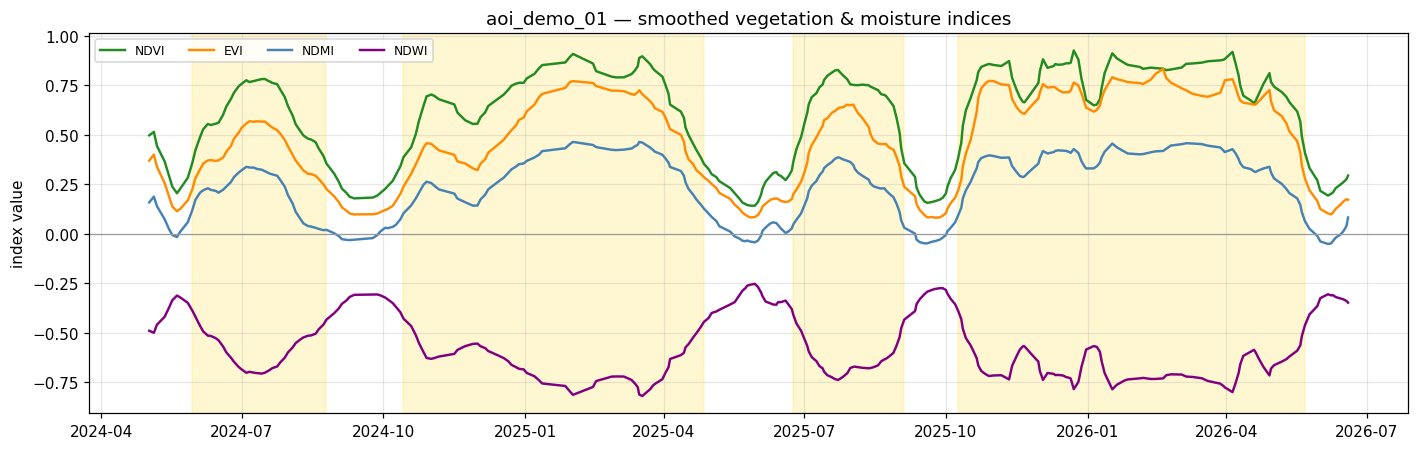

In [3]:
series = [("ndvi_smoothed", "NDVI", "forestgreen"),
          ("evi_smoothed", "EVI", "darkorange"),
          ("ndmi_smoothed", "NDMI", "steelblue"),
          ("ndwi_smoothed", "NDWI", "purple")]

fig, ax = plt.subplots(figsize=(13, 4.2))
for col, lab, c in series:
    ax.plot(sm.timestamp, sm[col], lw=1.6, color=c, label=lab)
for s in seas:
    ax.axvspan(pd.Timestamp(s["start_date"]), pd.Timestamp(s["end_date"]), color="gold", alpha=0.18)
ax.axhline(0, color="0.6", lw=0.8)
ax.set_title(f"{AOI} — smoothed vegetation & moisture indices")
ax.set_ylabel("index value")
ax.legend(loc="upper left", ncol=4, fontsize=8)
fig.tight_layout(); plt.show()

**What the multi-index view confirms**

- NDVI and EVI **co-move**, EVI lower (its soil/atmosphere correction reduces magnitude) — consistent, no contradiction.
- **NDMI** (canopy moisture) rises and falls with vegetation, supporting the activity windows rather than contradicting them.
- **NDWI stays negative year-round and anti-correlates** with NDVI, reaching its most-negative around vegetation peaks — confirming a **non-water, vegetated surface**.
- Low-quality timestamps are filled for analysis continuity; the original `valid_fraction` and gap windows remain separate evidence for confidence.


## 3. Evidence coverage

`valid_fraction` per solar day (share of AOI pixels not masked by cloud/SCL).
Green bars are **usable** (≥ threshold); grey bars were dropped by preprocessing.
This is data-quality evidence, not land risk.

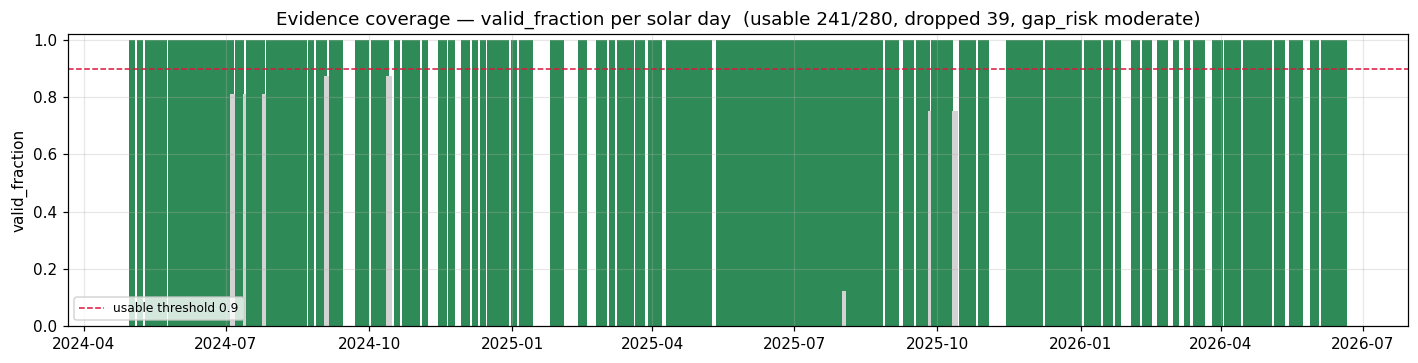

In [4]:
thr = quality["usable_valid_fraction_threshold"]
colors = ["seagreen" if u else "lightgray" for u in sm["is_usable"]]

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.bar(sm.timestamp, sm.valid_fraction, width=4, color=colors)
ax.axhline(thr, color="crimson", ls="--", lw=1, label=f"usable threshold {thr:g}")
ax.set_title(f"Evidence coverage — valid_fraction per solar day  "
             f"(usable {quality['usable_observation_count']}/{quality['total_observation_count']}, "
             f"dropped {quality['dropped_observation_count']}, gap_risk {quality['gap_risk']})")
ax.set_ylabel("valid_fraction"); ax.set_ylim(0, 1.02)
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout(); plt.show()

**What the coverage bars reveal**

- **Per-observation quality is excellent**: nearly every bar sits at `valid_fraction ≈ 1.0`. Only a handful fall below the 0.9 line and are dropped (grey) — e.g. a near-zero day in Aug 2025.
- So the **`moderate` gap_risk is about *cadence*, not cloud** — it comes from the white spaces and the 4 long gaps (temporal spacing), not contaminated scenes. When a scene exists over this AOI it is almost always fully usable.
- This is the distinction the product insists on: an **evidence limitation (timing), not a land problem**.

## 4. Spatial view from the cube

The cube stores raw-DN pixels, so we can render the AOI grid directly. Left: NDVI on the
peak-NDVI day. Right: per-pixel NDVI averaged over the 2 years. The AOI is small
(a few pixels at 10 m), so this is coarse — but it is real stored imagery, not a reduction.

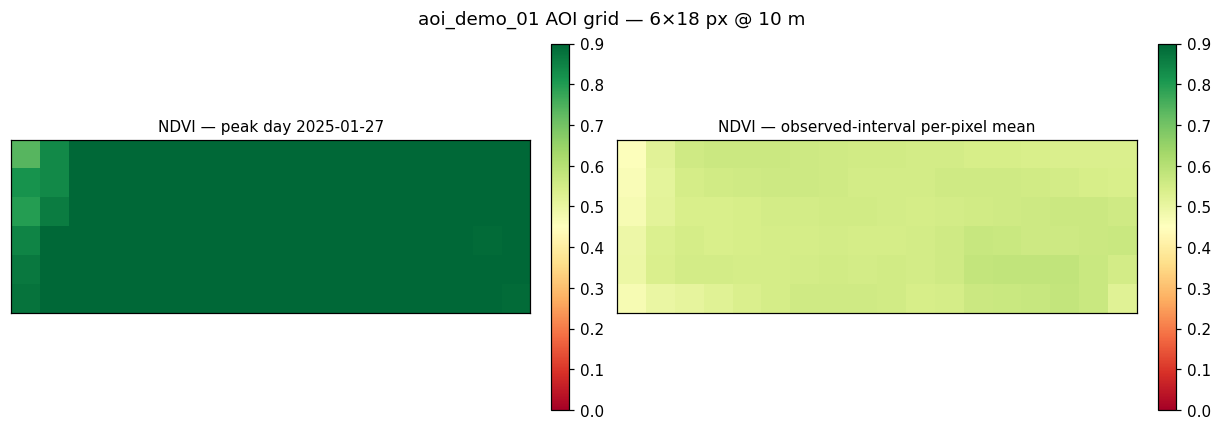

In [5]:
from farmtrust_core.ingest.cube_stats import apply_boa_offset

with np.errstate(invalid="ignore", divide="ignore"):
    red_all = apply_boa_offset(cube["B04"].values)
    nir_all = apply_boa_offset(cube["B08"].values)
    ndvi_all = (nir_all - red_all) / (nir_all + red_all)

ndvi_time_mean = np.nanmean(ndvi_all, axis=(1, 2))
ipeak = int(np.nanargmax(ndvi_time_mean))
peak_day = pd.Timestamp(cube.time.values[ipeak]).strftime("%Y-%m-%d")
ndvi_peak = ndvi_all[ipeak]
ndvi_mean_map = np.nanmean(ndvi_all, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for axx, arr, ttl in [(axes[0], ndvi_peak, f"NDVI — peak day {peak_day}"),
                      (axes[1], ndvi_mean_map, "NDVI — observed-interval per-pixel mean")]:
    im = axx.imshow(arr, cmap="RdYlGn", vmin=0, vmax=0.9)
    axx.set_title(ttl, fontsize=10); axx.set_xticks([]); axx.set_yticks([])
    axx.grid(False)
    fig.colorbar(im, ax=axx, fraction=0.046, pad=0.04)
fig.suptitle(f"{AOI} AOI grid — {cube.sizes['y']}×{cube.sizes['x']} px @ 10 m")
plt.show()


## 5. Assessment scorecard

The final lender-facing evidence object (`land_assessment.json`).

In [6]:
c = assess
print("=" * 64)
print(f"LAND ASSESSMENT — {c['aoi_id']}   [{c['assessment_status']}]")
print(f"interval: {c['interval']['start_date']} -> {c['interval']['end_date']}")
print("-" * 64)
print(f"land status        : {c['land_status']}")
print(f"trend (2y)         : {c['trend_2y']}")
lsp = c['latest_season_performance']
print(f"latest season      : {lsp['label']} (confirmation {lsp['confirmation_level']})")
print(f"season count       : {c['season_count']}")
cf = c['confidence']
print(f"confidence         : {cf['level']}  "
      f"[signal {cf['components']['signal_strength']}, "
      f"continuity {cf['components']['continuity']}, "
      f"window {cf['components']['activity_window_clarity']}]")
print(f"evidence coverage  : {c['satellite_evidence_coverage']['status']}")
print(f"interval max NDVI  : {c['metrics_summary']['interval_max_ndvi']:.3f}")
print("-" * 64)
print("risk flags:")
for r in c["risk_flags"]:
    print(f"   [{r['severity']}] {r['code']} — {r['reason']}")
print("confidence reasons:")
for r in cf["reasons"]:
    print(f"   - {r}")
print("=" * 64)

LAND ASSESSMENT — aoi_demo_01   [complete]
interval: 2024-05-01 -> 2026-06-20
----------------------------------------------------------------
land status        : active
trend (2y)         : improving
latest season      : good (confirmation strong)
season count       : 4
confidence         : medium  [signal high, continuity medium, window high]
evidence coverage  : fair
interval max NDVI  : 0.927
----------------------------------------------------------------
risk flags:
   [moderate] weak_activity_risk — The latest activity window is provisional, so final strength is not yet established.
confidence reasons:
   - Satellite evidence coverage is fair, so some activity-window interpretation remains cautious.
   - Usable observation count is solid (241).
   - Latest activity window has strong multi-index confirmation.
   - Latest activity window has provisional boundaries because the cycle is incomplete or overlaps evidence gaps.
   - The latest activity window overlaps one or more long 